# Identifying Risk Factors for Postpartum Depression

**Objective.** Estimate EPDS high-risk status using non-outcome maternal, socioeconomic, family, obstetric, and neonatal variables. Compare interpretable logistic regression and a shallow decision tree.

**Success criteria.** Prevent symptom leakage, use a fixed holdout set, report repeated cross-validation and holdout performance, and create four decision-relevant figures.

## Reproducibility and analysis plan

- Random seed: 680
- Target: EPDS score of 13 or higher
- Split: 75% development, 25% stratified holdout
- Validation: repeated stratified 5-fold cross-validation, five repeats
- Models: regularized logistic regression and depth-limited decision tree
- Leakage control: remove EPDS, current PHQ-9, identifiers, and selected postpartum symptom proxies
- Categorical cleaning: documented None responses, explicit unresolved missing values, and fold-specific rare-level grouping

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "code"))
import analyze_postpartum_depression as ppd
pd.set_option('display.max_colwidth', 80)
print(f'Project root: {ROOT}')
print(f'Random seed: {ppd.SEED}')

Project root: /Volumes/Extreme Pro/Box Sync/School/DSC/DSC 680/Week 9 - 11/Project 3/DSC680_Postpartum_Depression_Milestone_2
Random seed: 680


## Data preparation and leakage audit

The dataset is the Mendeley Data version 3 release. Blanks are mapped to None only when the data dictionary documents that response. The older-child field uses an explicit unavailable or not-applicable level. Remaining categorical blanks are labeled Missing / not reported inside each training fold. Spelling and capitalization variants are normalized, invalid values are recoded as missing, and levels appearing fewer than five times are grouped. The published EPDS category contains one disagreement with the documented cutoff, so the numeric score cutoff is used consistently.

In [2]:
df, X, y = ppd.load_and_prepare()
summary = {
    'rows': len(df), 'raw_columns': df.shape[1], 'predictors': X.shape[1],
    'high_risk_n': int(y.sum()), 'high_risk_rate': round(y.mean(), 4),
    'raw_missing_cells': int(df.attrs['raw_missing_cells']),
    'raw_predictor_missing_cells': int(df.attrs['raw_predictor_missing_cells']),
    'predictor_missing_cells': int(X.isna().sum().sum()),
    'duplicates': int(df.duplicated().sum()),
    'label_disagreements': df.attrs['target_label_disagreements'],
}
pd.Series(summary).to_frame('value')

,value
rows,800.0000
raw_columns,70.0000
predictors,38.0000
high_risk_n,349.0000
high_risk_rate,0.4362
raw_missing_cells,4312.0000
raw_predictor_missing_cells,4089.0000
predictor_missing_cells,206.0000
duplicates,0.0000
label_disagreements,1.0000


In [3]:
cleaning_audit = df.attrs['cleaning_audit']
cleaning_audit[cleaning_audit.records_affected > 0].reset_index(drop=True)

,column,action,records_affected,detail
0,Disease before pregnancy,Invalid value recoded as missing,1,1.2
1,Occupation before latest pregnancy,Category normalized,1,House wife -> Housewife
2,Occupation After Your Latest Childbirth,Category normalized,1,House wife -> Housewife
3,Education Level,Category normalized,11,Primary school -> Primary School
4,Education Level,Category normalized,9,High school -> High School
5,Husband's education level,Category normalized,6,Primary school -> Primary School
6,Husband's education level,Category normalized,8,High school -> High School
7,Total children,Category normalized,9,More than Two -> More than two
8,History of pregnancy loss,Category normalized,24,Still-born Delivery -> Stillbirth
9,History of pregnancy loss,Category normalized,5,Still-born delivery -> Stillbirth


In [4]:
leakage_audit = pd.DataFrame({
    'excluded_field': [c.strip() for c in ppd.EXCLUDED_FIELDS],
    'reason': (['Identifier'] + ['Direct screening component or outcome'] * len(ppd.SCREENING_LEAKAGE)
               + ['Contemporaneous postpartum symptom proxy'] * len(ppd.POSTPARTUM_PROXY_FIELDS))
})
leakage_audit.groupby('reason').size().to_frame('fields_excluded')

,fields_excluded
reason,
Contemporaneous postpartum symptom proxy,8
Direct screening component or outcome,23
Identifier,1


## Descriptive analysis

These subgroup rates are descriptive associations. They do not adjust for other variables and do not establish causation.

In [5]:
risk_summary = ppd.risk_factor_summary(df, y)
risk_summary.sort_values(['factor', 'high_risk_rate'], ascending=[True, False]).head(20)

,factor,level,n,high_risk_rate
7,Ability to confide,No,255,0.564706
8,Ability to confide,Yes,544,0.376838
4,Abuse reported,No,359,0.640669
5,Abuse reported,Yes,403,0.287841
6,Abuse reported,Missing,38,0.078947
3,Depression before pregnancy,Positive,81,0.691358
2,Depression before pregnancy,Negative,719,0.407510
1,Depression during pregnancy,Positive,184,0.586957
0,Depression during pregnancy,Negative,616,0.391234
12,Support received,Low,154,0.571429


## Model evaluation

In [6]:
metrics, fitted, predictions, X_train, X_test, y_train, y_test = ppd.evaluate_models(X, y)
for name, values in predictions.items():
    lo, hi = ppd.bootstrap_auc(y_test, values['prob'])
    metrics.loc[metrics.model.eq(name), 'test_auc_ci_low'] = lo
    metrics.loc[metrics.model.eq(name), 'test_auc_ci_high'] = hi
metrics[['model', 'cv_roc_auc_mean', 'cv_roc_auc_sd', 'cv_recall_mean',
         'test_roc_auc', 'test_auc_ci_low', 'test_auc_ci_high',
         'test_recall', 'test_precision', 'test_f1', 'test_brier_score']].round(3)

,model,cv_roc_auc_mean,cv_roc_auc_sd,cv_recall_mean,test_roc_auc,test_auc_ci_low,test_auc_ci_high,test_recall,test_precision,test_f1,test_brier_score
0,Logistic regression,0.774,0.032,0.694,0.760,0.690,0.826,0.598,0.650,0.623,0.198
1,Decision tree,0.729,0.040,0.637,0.731,0.662,0.800,0.736,0.552,0.631,0.216


The logistic model provides the stronger repeated cross-validation result. The shallow tree has slightly higher holdout recall at the cost of more false positives. Model choice should follow the intended screening workflow and the cost of missed high-risk cases.

In [7]:
terms = ppd.logistic_terms(fitted['Logistic regression'])
terms.head(15).round(3)

,term,coefficient,odds_ratio_per_encoded_unit,absolute_coefficient
81,Abuse_Missing / not reported,-0.863,0.422,0.863
120,Depression before pregnancy (PHQ2)_Positive,0.642,1.901,0.642
69,Relationship with husband_Good,-0.607,0.545,0.607
64,Relationship with the in-laws_Good,-0.602,0.547,0.602
122,Depression during pregnancy (PHQ2)_Positive,0.558,1.747,0.558
82,Abuse_Yes,-0.541,0.582,0.541
96,Fear of pregnancy_Yes,0.537,1.711,0.537
6,Education Level_University,0.523,1.686,0.523
72,Recieved Support_Low,0.520,1.682,0.520
84,Trust and share feelings_Yes,-0.495,0.609,0.495


Regularized coefficients are conditional, model-dependent associations. Categorical odds ratios use the one-hot encoder's omitted reference level and should not be read as causal effects.

## Visual results

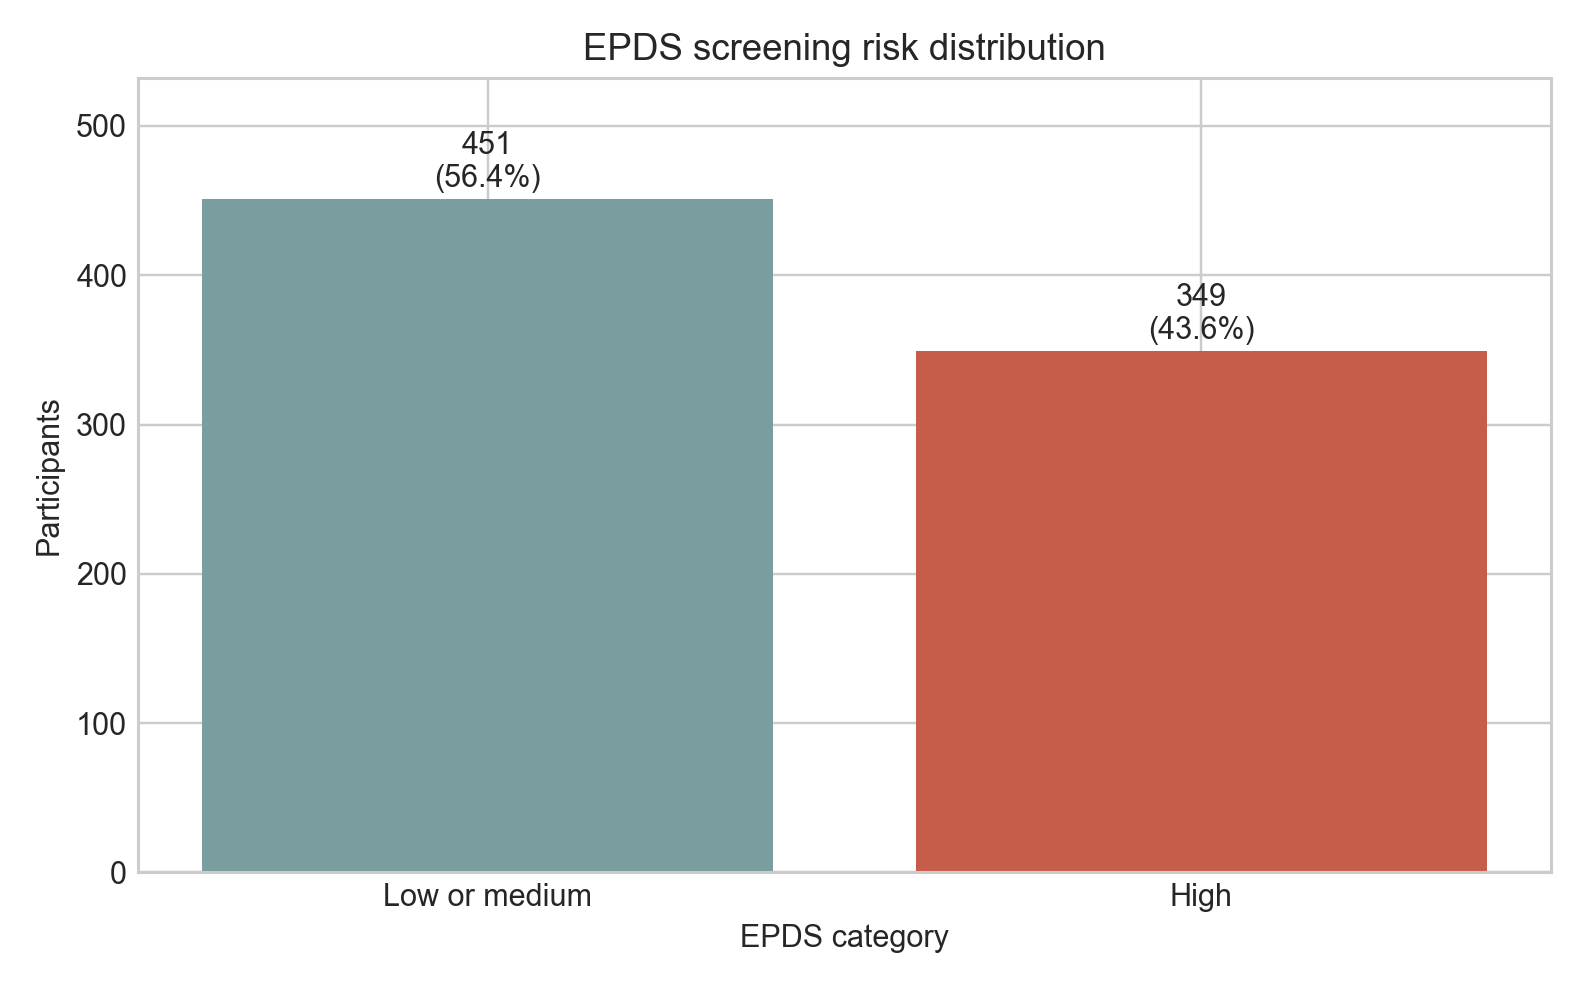

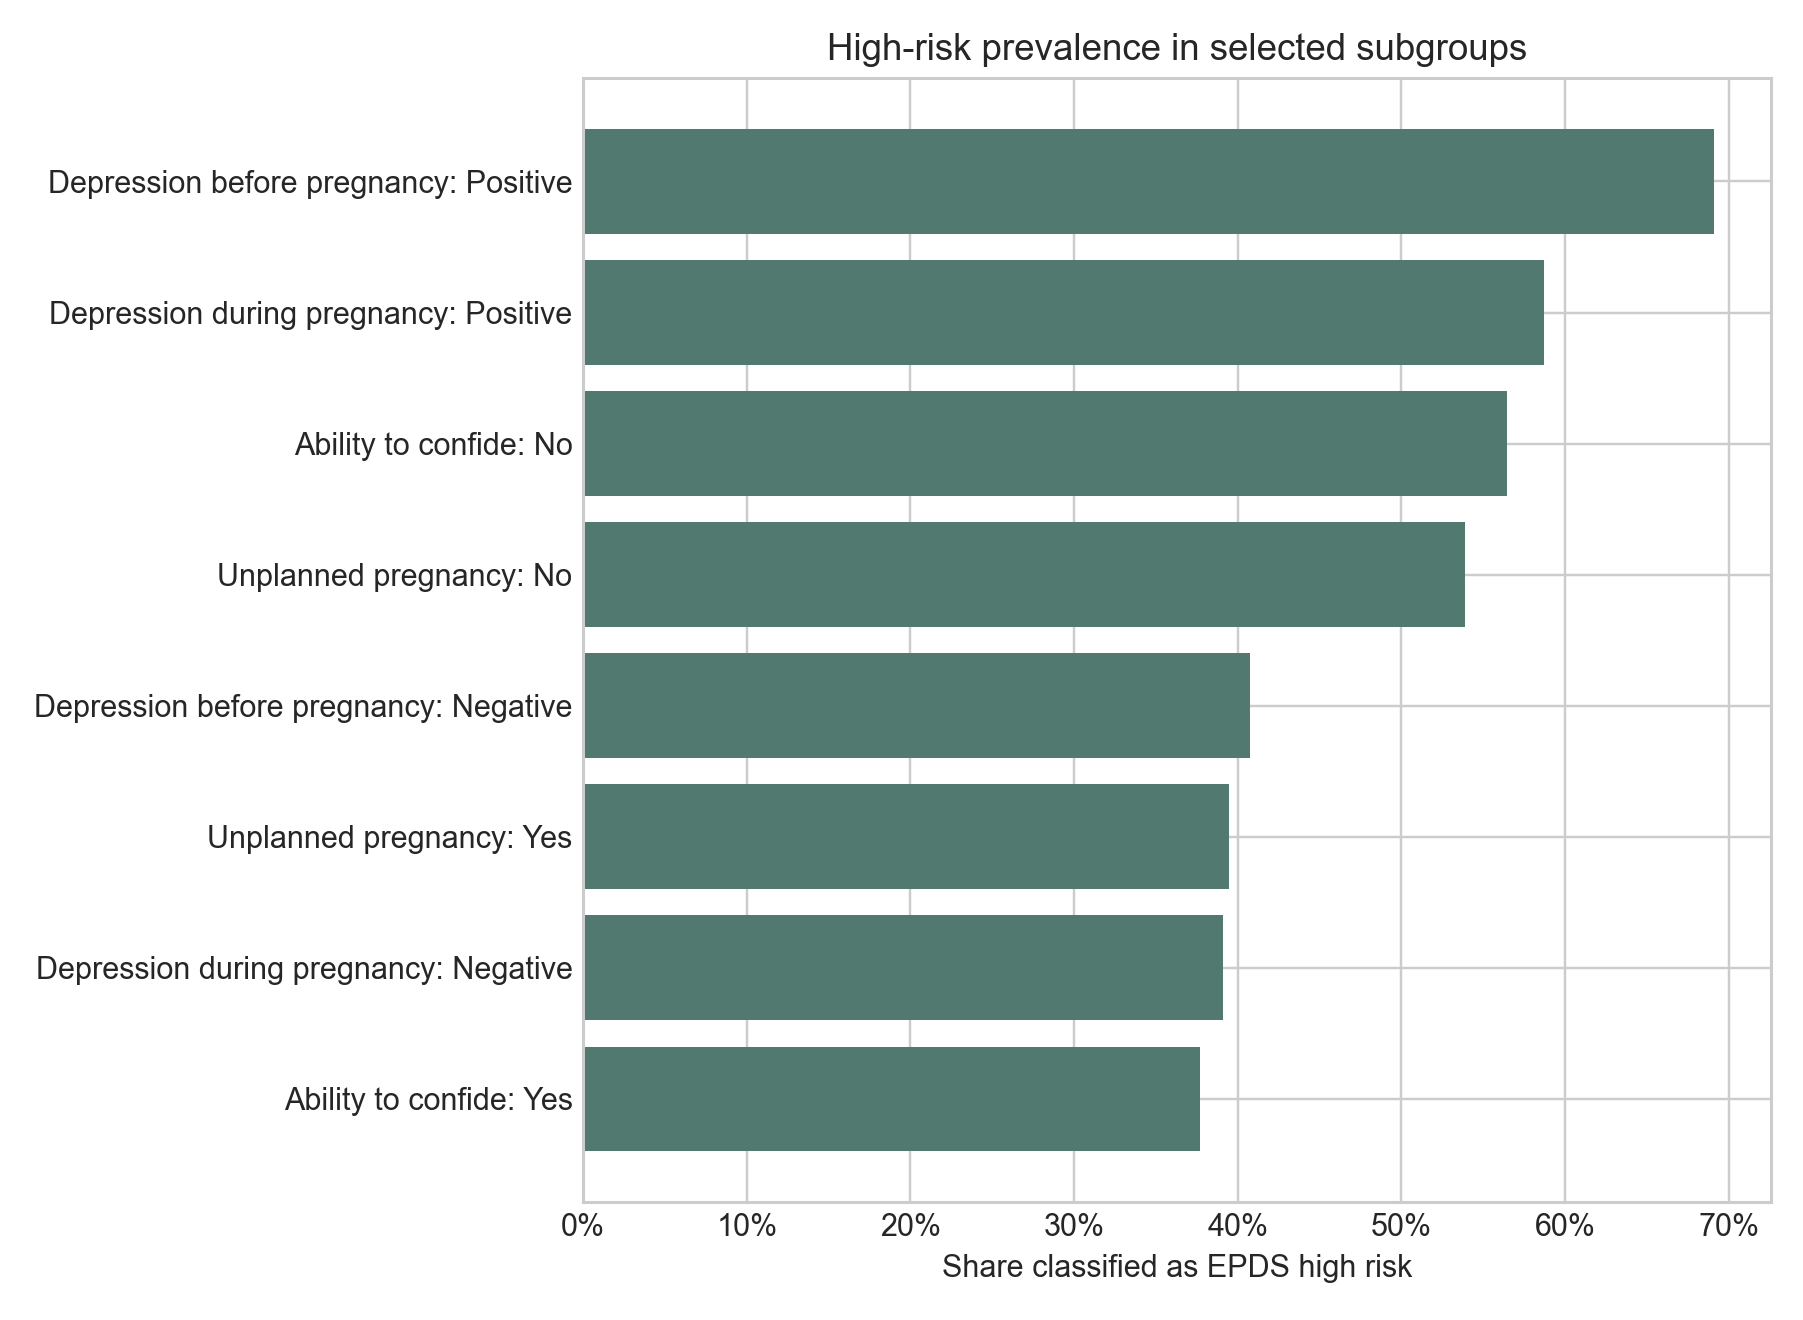

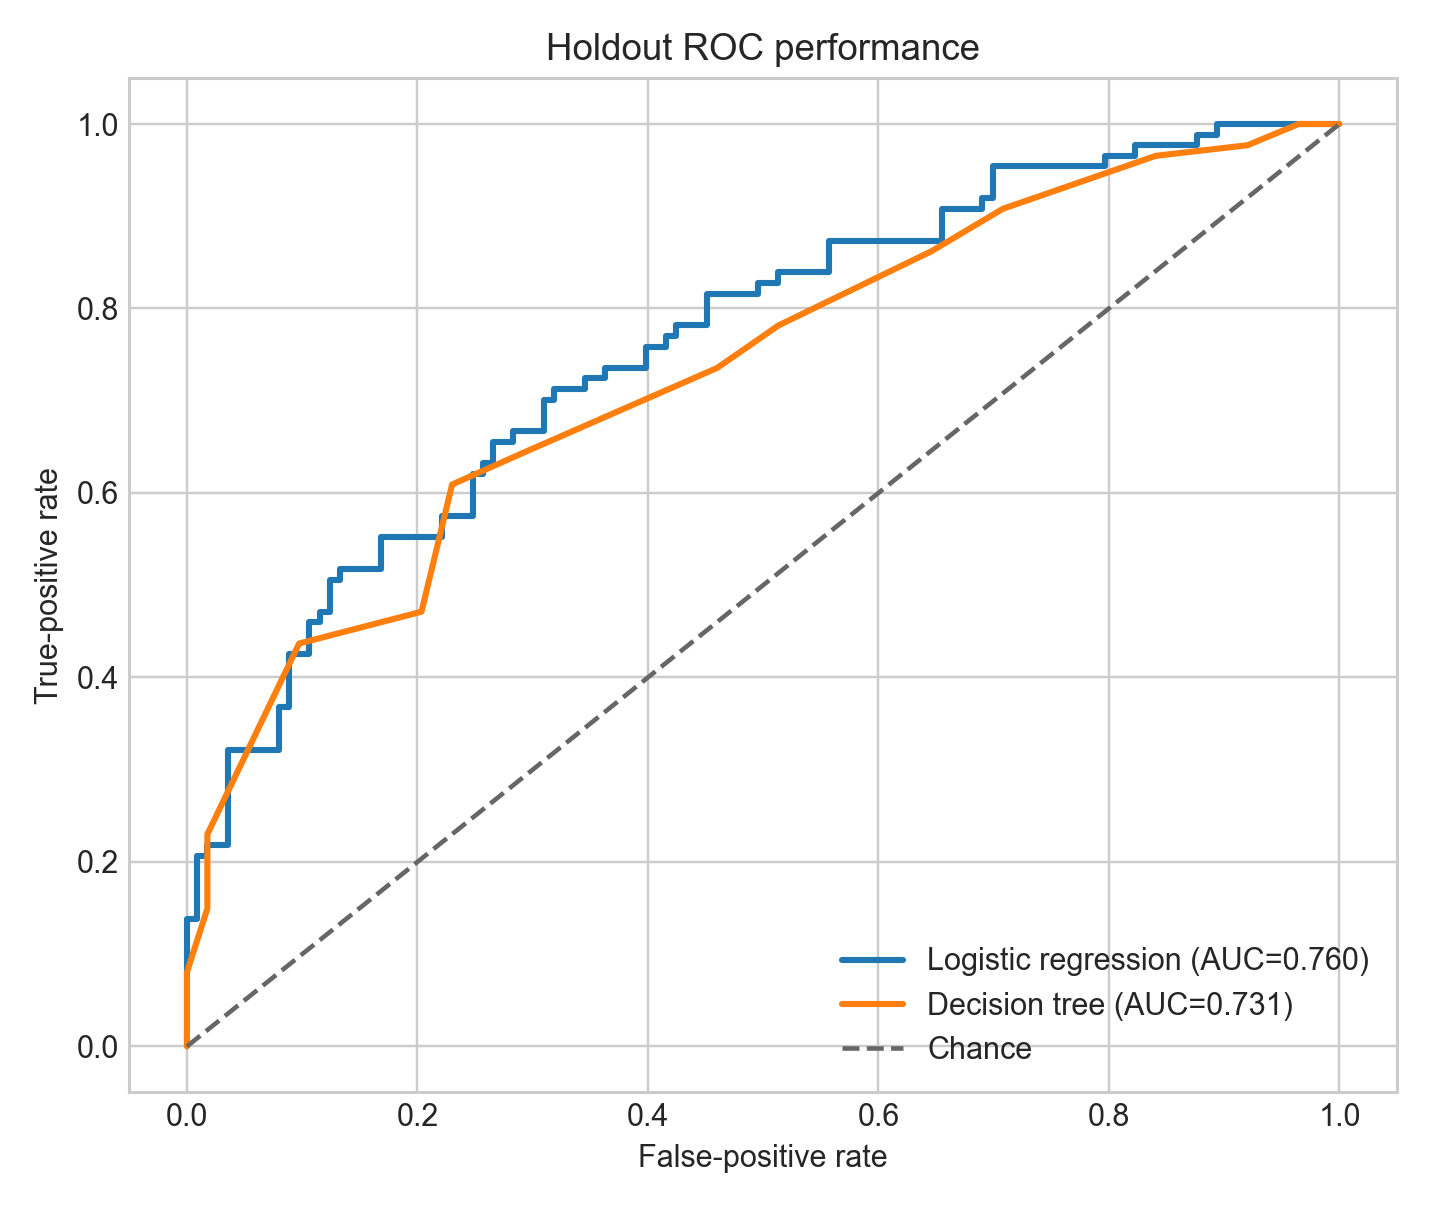

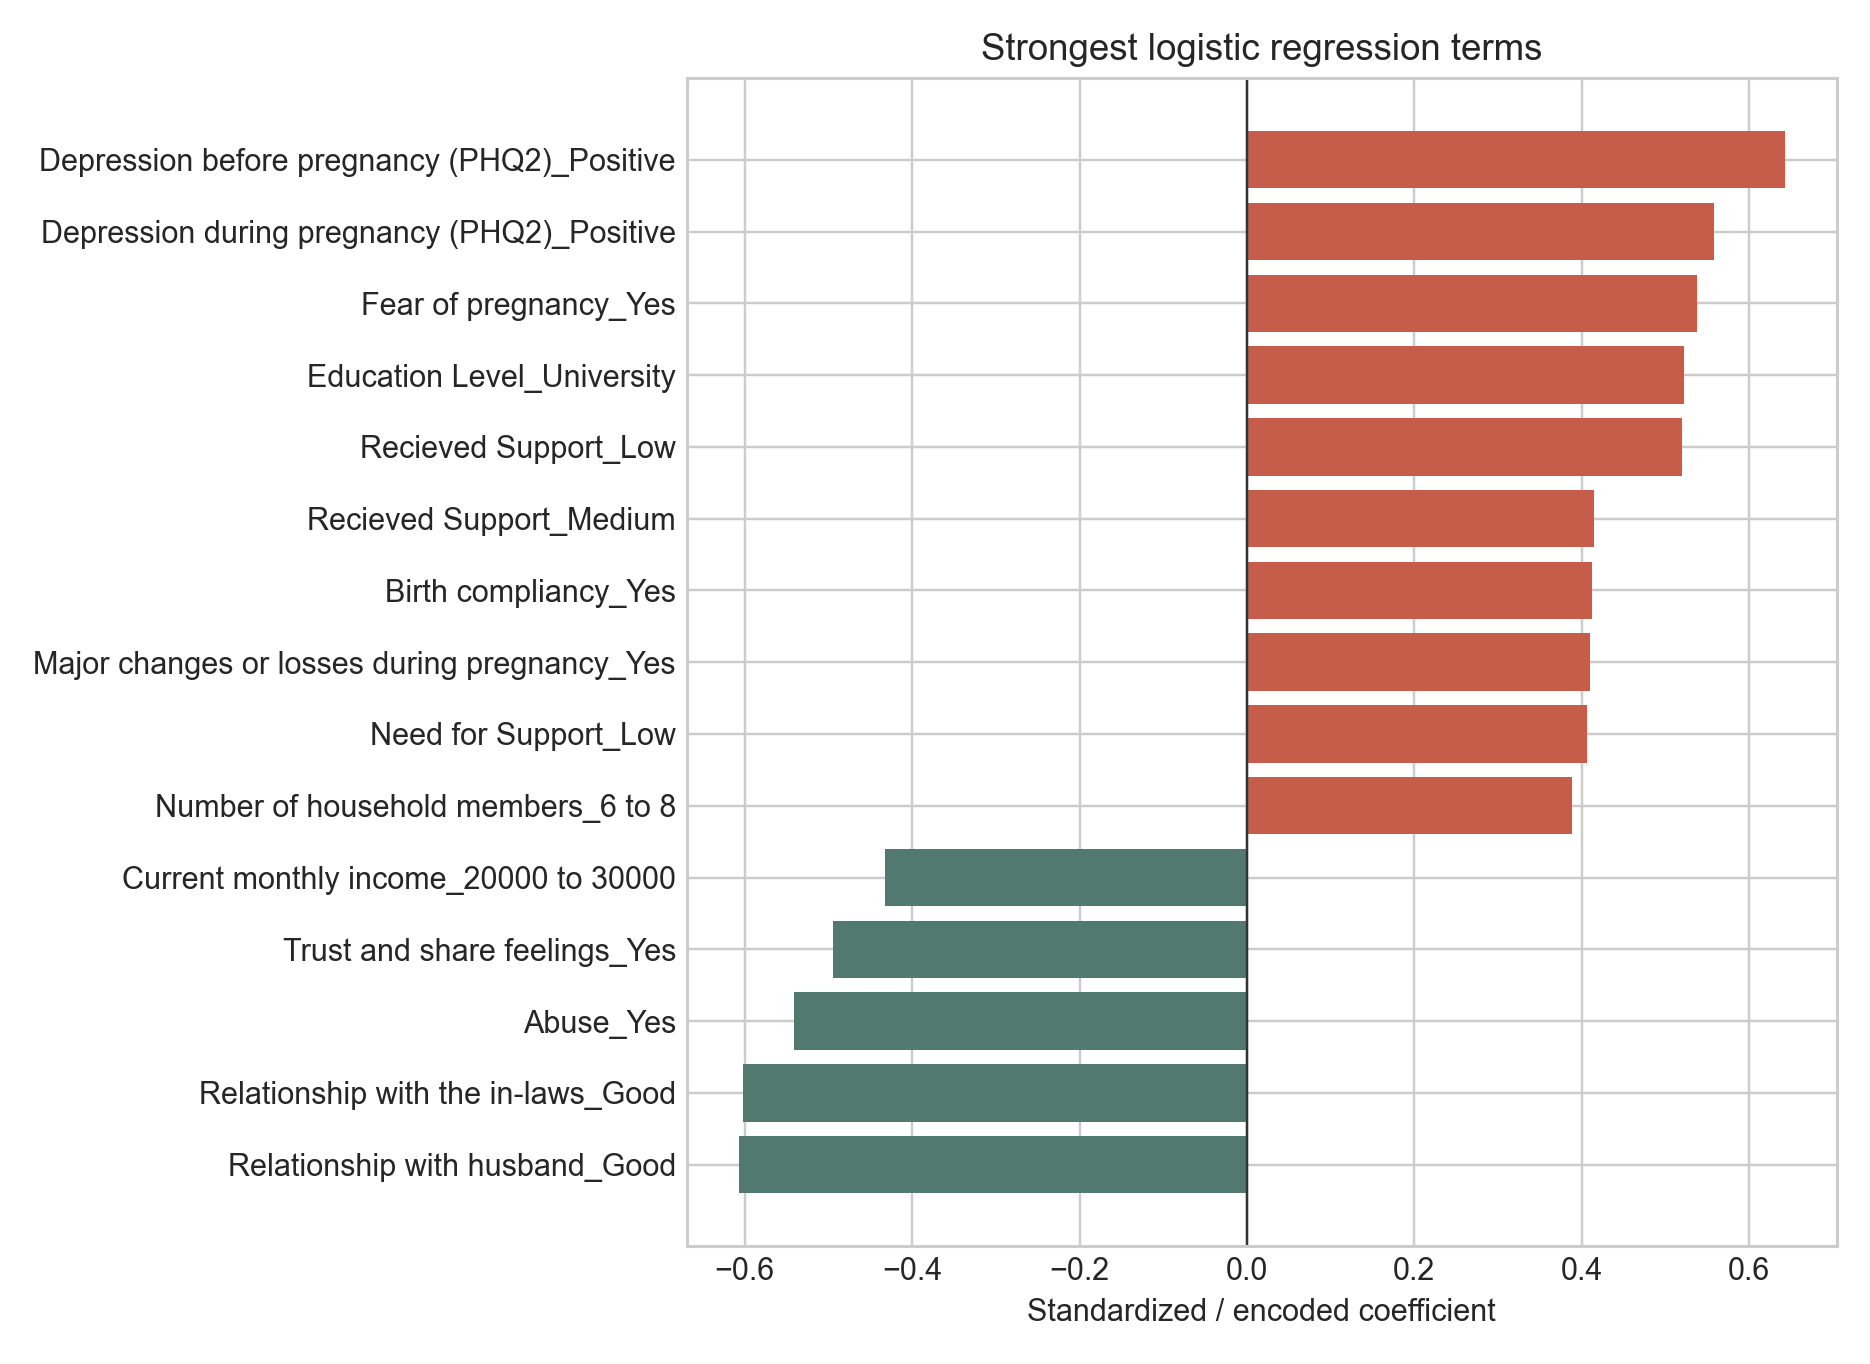

In [8]:
ppd.FIGURES.mkdir(parents=True, exist_ok=True)
ppd.create_figures(df, X, y, metrics, fitted, predictions, X_test, y_test, risk_summary)
for filename in ['figure_1_epds_distribution.png', 'figure_2_selected_risk_factors.png',
                 'figure_3_roc_curves.png', 'figure_4_logistic_terms.png']:
    display(Image(filename=str(ppd.FIGURES / filename), width=760))

## Results and next steps

The models show moderate discrimination after strict leakage control. Prior depression screening, family relationships, support, fear of pregnancy, and major pregnancy changes contribute to the fitted model. External validation is required before any operational use.

Next steps:

- validate the feature definitions and missing-value meaning with the dataset authors;
- test the model prospectively in a defined clinical population;
- audit calibration and subgroup performance before deployment;
- retain validated EPDS screening and clinical follow-up as the decision pathway.